In [2]:
# import zipfile

# zip_path = "/content/dataset2.zip"
# extract_path = "/content"

# with zipfile.ZipFile(zip_path, 'r') as zip_ref:
#     zip_ref.extractall(extract_path)

# print("Done")

In [3]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras import layers, models, optimizers
from sklearn.metrics import confusion_matrix, classification_report

In [4]:
# config
base_path = 'dataset' # Path to your top-level folder
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

In [5]:
# data loading

train_ds = tf.keras.utils.image_dataset_from_directory(
    os.path.join(base_path, 'train'),
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='binary',
    shuffle=True
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    os.path.join(base_path, 'valid'),
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='binary'
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    os.path.join(base_path, 'test'),
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='binary',
    shuffle=False
)

Found 352 files belonging to 2 classes.
Found 98 files belonging to 2 classes.
Found 54 files belonging to 2 classes.


In [6]:
# optimization

AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.prefetch(buffer_size=AUTOTUNE)

In [7]:
# augmentation

data_augmentation = models.Sequential([
    layers.RandomFlip("horizontal_and_vertical"),
    layers.RandomRotation(0.2),
    layers.RandomBrightness(factor=0.3), # Added as requested
    layers.RandomContrast(0.2),
    layers.RandomZoom(0.1),
])

In [8]:
# loading convnext tiny

base_model = tf.keras.applications.ConvNeXtTiny(
    include_top=False,
    weights='imagenet',
    input_shape=(224, 224, 3)
)
base_model.trainable = False

model = models.Sequential([
    layers.Input(shape=(224, 224, 3)),
    data_augmentation,
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.BatchNormalization(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(1, activation='sigmoid')
])

111650432/111650432 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step


In [9]:
# training

model.compile(
    optimizer=optimizers.Adam(learning_rate=1e-3),
    loss='binary_crossentropy',
    metrics=['accuracy', tf.keras.metrics.Recall()]
)

print("\n--- Starting Training ---")
history = model.fit(train_ds, validation_data=val_ds, epochs=10)


--- Starting Training ---
Epoch 1/10
11/11 ━━━━━━━━━━━━━━━━━━━━ 33s 1s/step - accuracy: 0.8523 - loss: 0.2973 - recall: 0.8626 - val_accuracy: 0.9082 - val_loss: 0.2666 - val_recall: 0.9592
Epoch 2/10
11/11 ━━━━━━━━━━━━━━━━━━━━ 5s 416ms/step - accuracy: 0.9801 - loss: 0.0659 - recall: 0.9725 - val_accuracy: 0.9184 - val_loss: 0.2055 - val_recall: 0.9592
Epoch 3/10
11/11 ━━━━━━━━━━━━━━━━━━━━ 5s 418ms/step - accuracy: 0.9631 - loss: 0.0748 - recall: 0.9670 - val_accuracy: 0.9490 - val_loss: 0.1753 - val_recall: 0.9592
Epoch 4/10
11/11 ━━━━━━━━━━━━━━━━━━━━ 5s 422ms/step - accuracy: 0.9801 - loss: 0.0394 - recall: 0.9945 - val_accuracy: 0.9286 - val_loss: 0.1768 - val_recall: 0.8980
Epoch 5/10
11/11 ━━━━━━━━━━━━━━━━━━━━ 5s 409ms/step - accuracy: 0.9830 - loss: 0.0362 - recall: 0.9835 - val_accuracy: 0.9388 - val_loss: 0.1641 - val_recall: 0.8980
Epoch 6/10
11/11 ━━━━━━━━━━━━━━━━━━━━ 5s 422ms/step - accuracy: 0.9886 - loss: 0.0262 - recall: 1.0000 - val_accuracy: 0.9592 - val_loss: 0.1403 

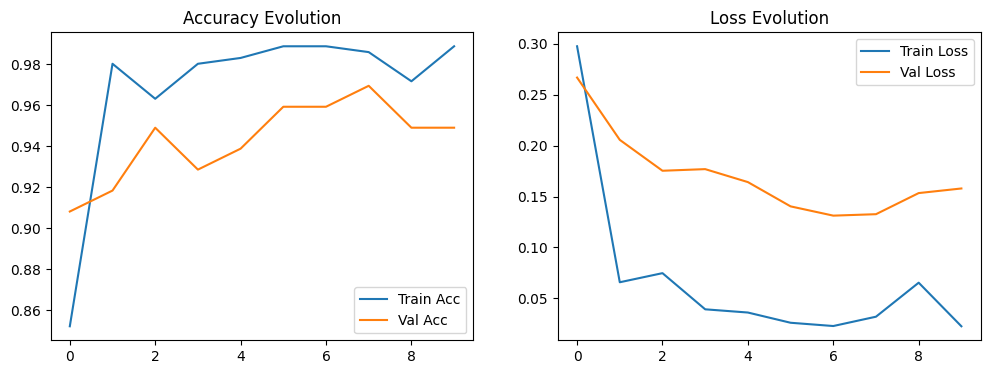

2/2 ━━━━━━━━━━━━━━━━━━━━ 11s 6s/step


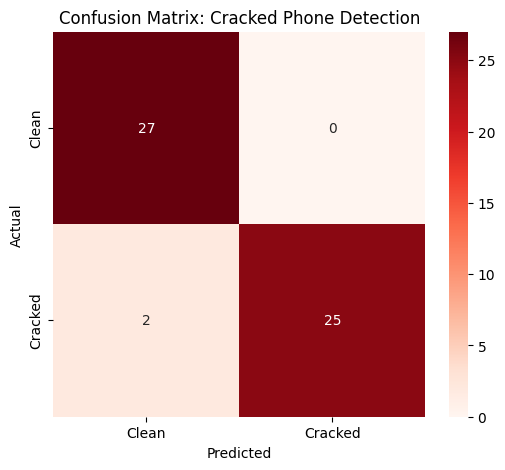


--- Final Test Metrics ---
              precision    recall  f1-score   support

       Clean       0.93      1.00      0.96        27
     Cracked       1.00      0.93      0.96        27

    accuracy                           0.96        54
   macro avg       0.97      0.96      0.96        54
weighted avg       0.97      0.96      0.96        54



In [10]:
# evaluation

def run_project_evaluation(model, history, test_ds):
    plt.figure(figsize=(12, 4))
    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'], label='Train Acc')
    plt.plot(history.history['val_accuracy'], label='Val Acc')
    plt.title('Accuracy Evolution')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Val Loss')
    plt.title('Loss Evolution')
    plt.legend()
    plt.show()

    # Confusion Matrix
    y_true = np.concatenate([y for x, y in test_ds], axis=0)
    y_pred = (model.predict(test_ds) > 0.5).astype(int)

    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Reds',
                xticklabels=['Clean', 'Cracked'], yticklabels=['Clean', 'Cracked'])
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title('Confusion Matrix: Cracked Phone Detection')
    plt.show()

    print("\n--- Final Test Metrics ---")
    print(classification_report(y_true, y_pred, target_names=['Clean', 'Cracked']))

run_project_evaluation(model, history, test_ds)

In [13]:
model.save('cracked_phone_detector_model.keras')
print("Model saved successfully to 'cracked_phone_detector_model.keras'")

Model saved successfully to 'cracked_phone_detector_model.keras'


In [11]:
# import os
# import numpy as np
# import matplotlib.pyplot as plt
# import seaborn as sns
# import tensorflow as tf
# from tensorflow.keras import layers, models, optimizers
# from sklearn.metrics import confusion_matrix, classification_report

# # --- 1. CONFIGURATION ---
# base_path = 'dataset' # Path to your top-level folder
# IMG_SIZE = (224, 224)
# BATCH_SIZE = 32

# # --- 2. DATA LOADERS ---
# # These handle different image sizes automatically by resizing to IMG_SIZE
# train_ds = tf.keras.utils.image_dataset_from_directory(
#     os.path.join(base_path, 'train'),
#     image_size=IMG_SIZE,
#     batch_size=BATCH_SIZE,
#     label_mode='binary',
#     shuffle=True
# )

# val_ds = tf.keras.utils.image_dataset_from_directory(
#     os.path.join(base_path, 'valid'), # Using your folder name 'valid'
#     image_size=IMG_SIZE,
#     batch_size=BATCH_SIZE,
#     label_mode='binary'
# )

# test_ds = tf.keras.utils.image_dataset_from_directory(
#     os.path.join(base_path, 'test'),
#     image_size=IMG_SIZE,
#     batch_size=BATCH_SIZE,
#     label_mode='binary',
#     shuffle=False # Keep false for clean evaluation
# )

# # Optimization
# AUTOTUNE = tf.data.AUTOTUNE
# train_ds = train_ds.prefetch(buffer_size=AUTOTUNE)
# val_ds = val_ds.prefetch(buffer_size=AUTOTUNE)

# # --- 3. AUGMENTATION & MODEL ---
# data_augmentation = models.Sequential([
#     layers.RandomFlip("horizontal_and_vertical"),
#     layers.RandomRotation(0.2),
#     layers.RandomBrightness(factor=0.3), # Added as requested
#     layers.RandomContrast(0.2),
#     layers.RandomZoom(0.1),
# ])

# # Loading ConvNeXt Tiny (V1/V2 Logic)
# base_model = tf.keras.applications.ConvNeXtTiny(
#     include_top=False,
#     weights='imagenet',
#     input_shape=(224, 224, 3)
# )
# base_model.trainable = False

# model = models.Sequential([
#     layers.Input(shape=(224, 224, 3)),
#     data_augmentation,
#     base_model,
#     layers.GlobalAveragePooling2D(),
#     layers.BatchNormalization(),
#     layers.Dense(256, activation='relu'),
#     layers.Dropout(0.4),
#     layers.Dense(1, activation='sigmoid')
# ])

# # --- 4. TRAINING PHASE ---
# model.compile(
#     optimizer=optimizers.Adam(learning_rate=1e-3),
#     loss='binary_crossentropy',
#     metrics=['accuracy', tf.keras.metrics.Recall()]
# )

# print("\n--- Starting Training ---")
# history = model.fit(train_ds, validation_data=val_ds, epochs=10)

# # --- 5. VISUALIZATION & METRICS ---

# def run_project_evaluation(model, history, test_ds):
#     # 1. Plot Training History
#     plt.figure(figsize=(12, 4))
#     plt.subplot(1, 2, 1)
#     plt.plot(history.history['accuracy'], label='Train Acc')
#     plt.plot(history.history['val_accuracy'], label='Val Acc')
#     plt.title('Accuracy Evolution')
#     plt.legend()

#     plt.subplot(1, 2, 2)
#     plt.plot(history.history['loss'], label='Train Loss')
#     plt.plot(history.history['val_loss'], label='Val Loss')
#     plt.title('Loss Evolution')
#     plt.legend()
#     plt.show()

#     # 2. Confusion Matrix
#     y_true = np.concatenate([y for x, y in test_ds], axis=0)
#     y_pred = (model.predict(test_ds) > 0.5).astype(int)

#     cm = confusion_matrix(y_true, y_pred)
#     plt.figure(figsize=(6, 5))
#     sns.heatmap(cm, annot=True, fmt='d', cmap='Reds',
#                 xticklabels=['Clean', 'Cracked'], yticklabels=['Clean', 'Cracked'])
#     plt.xlabel('Predicted')
#     plt.ylabel('Actual')
#     plt.title('Confusion Matrix: Cracked Phone Detection')
#     plt.show()

#     # 3. Text Report
#     print("\n--- Final Test Metrics ---")
#     print(classification_report(y_true, y_pred, target_names=['Clean', 'Cracked']))

# # Run the evaluation
# run_project_evaluation(model, history, test_ds)